# Fusion NIRCam / NIRSpec Tutorial

In [3]:
%load_ext autoreload  
%autoreload 2
import pandas
import sklearn
import pickle
import numpy as np
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from ipywidgets import interact
from matchmaker import *
from astropy.io import fits
import matplotlib.patches as patches
from scipy import ndimage
from copy import deepcopy as copy
import math
import image_auto as image
import scipy
import sys
import imtools as im
#sys.path.append('/Users/jmlascar/Fusion_JWST/NewRegularization')
from preprocess_only import Preprocess

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Selecting data

To perform fusion, you will need data that are superposed on the plane of the sky, and with NIRSpec and NIRCam filters that overlap. (include here a word about filter overlap)

In the JWST MAST archive [(https://mast.stsci.edu/portal/Mashup/Clients/Mast/Portal.html)], go to Advanced Search and select parameters you'd be interested in for your purpose (such as a target classification, a specific proposal ID...)
Then, at the top left of the window, click on "Export Table". This will download a csv file of your search result. Inputing this table into the code below will return targets for which there is data on which fusion can be performed.

(Note that since this matching is based on the coordinates of the objects in the sky, it cannot match moving objects whose coordinates would be different in NIRSpec and NIRCam. For such objects (such as the fusion of Titan data performed in Landry et al 2026), you will have to select the data with matching filters by looking for it directly in the archive.)

In [107]:
#To use the matchmaker, uncomment the following lines:

#Matches_np,Info,NIRCam_df,NIRSpec_df=get_pairs('MAST_2026-02-19T1511_full.csv')
#DF_list=organize(Matches_np,NIRCam_df,NIRSpec_df)
#with open("matches_fusion.p","wb") as f:
#    pickle.dump(DF_list,f)

  0%|          | 0/10099 [00:00<?, ?it/s]

In [4]:
#To load a match-maker result:

#with open("matches_fusion.p","rb") as f:
#    DF_list=pickle.load(f)

In [5]:
#To visualise fusion candidates:

#def visualize(NC_Target):
#    display(DF_list[NC_Target])
#interact(visualize,NC_Target=sorted(DF_list.keys()))

interactive(children=(Dropdown(description='NC_Target', options=('1181-MERGED-APT-CLEAN-CLEAN', '21_3_23_mediu…

<function __main__.visualize(NC_Target)>

## Downloading Data

Once you've selected your source of choice for fusion, it's time to download the data, then to

Have the whole list put here, then underneath, have just one for the sky selection

In [45]:
Throughputs_path="Throughputs" #directory where the Throughputs are

path_data="/Users/jmlascar/Fusion_JWST/Data_Landry/"#directory where the data is
NIRCam_path = [path_data+#NIRCam data should be in a list
               "Level3_CLEAR-F182M-B_i2d_aligned.fits",
              path_data+"Level3_CLEAR-F187N-B_i2d_aligned.fits",
              path_data+"Level3_CLEAR-F210M-B_i2d_aligned.fits"]
NIRSpec_path = path_data+"/jw01288-c1005_t014_nirspec_g235h-f170lp_s3d.fits"

## Configuration 

### Selecting Sky Area

Here, have the data be loaded, and the person interacts to pick the area by modifying the angle / target / size. Then, have these be parameters for the fusion process. 

**Moving Targets:** Because moving targets may have different coordinates in the NIRSpec and NIRCam images, for the allignment method in the preprocessing to work, the target should be at the center (approximately) of the NIRCam image. If that is not the case as is, please crop it.

In [46]:
file_NC=[fits.open(NIRCam_path[i]) for i in range(len(NIRCam_path))]
file_NS=fits.open(NIRSpec_path) 
data_NS=file_NS[1].data

In [47]:
def pick_crop(angle,channel,x_center_pix_coord,y_center_pix_coord,width=14,height=14):
    def show_pixel(pixel_i,pixel_j):
        data_NS=file_NS[1].data
        center_pix_coord = np.array([x_center_pix_coord, y_center_pix_coord])
        semi_height = (height)//2
        semi_width=(width)//2
        Cropped_Image_NS=cut_rotate_NS(data_NS,height,width,angle,center_pix_coord)
        fig,ax=plt.subplots(1,3,figsize=(12,5))
        ax[0].imshow(data_NS[channel,:,:],cmap="grey")
        ax[0].set_title(f"NIRSpec data, channel {channel}")
        ax[0].add_patch(patches.Rectangle((center_pix_coord[0]-semi_width, center_pix_coord[1]-semi_height),width, height, 
                                          rotation_point="center",angle=angle,
                                           linewidth=1, edgecolor='r', facecolor='none'))
        ax[1].imshow(Cropped_Image_NS[channel,:,:],cmap="grey")
        ax[1].set_title(f"cropped NIRSpec data, channel {channel}")
        ax[2].set_title(f"NIRSpec spectra")
        
        ax[2].plot(Cropped_Image_NS[:,pixel_j,pixel_i])
        ax[1].scatter(pixel_i,pixel_j,color="red",marker="+")
        plt.show()
        print("Once you are satisfied, copy-paste this code to perform the pre-processing and check the NIRCam image:")
        print(f"Yh,Ym,wavelengths,wave_slice=Preprocess({angle},{x_center_pix_coord},{y_center_pix_coord},{height},{width},"+
                     "NIRSpec_path,NIRCam_path,Throughputs_path,debug=False)")
    interact(show_pixel,pixel_i=(0,height-1,1),pixel_j=(0,width-1,1))
interact(pick_crop,#width=(0,data_NS.shape[1]-1,1),height=(0,data_NS.shape[2]-1,1),
         angle=(0,180,1),
         channel=(0,data_NS.shape[0]-1,1),
        x_center_pix_coord=(0,data_NS.shape[2]-1,.5),
         y_center_pix_coord=(0,data_NS.shape[1]-1,.5),preprocess=[True,False])

interactive(children=(IntSlider(value=90, description='angle', max=180), IntSlider(value=1906, description='ch…

<function __main__.pick_crop(angle, channel, x_center_pix_coord, y_center_pix_coord, width=14, height=14)>

In [55]:
Yh,Ym,wavelengths,wave_slice=Preprocess(0,86.5,176.5,10,NIRSpec_path,NIRCam_path,Throughputs_path,
                                       debug=False)

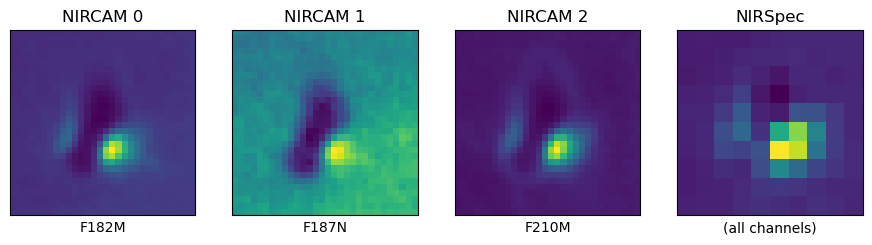

In [56]:
#images are aligned by calculating the shift measured by the phase cross correlation
#Manuel Guizar-Sicairos, Samuel T. Thurman, and James R. Fienup, 
#“Efficient subpixel image registration algorithms,” Optics Letters 33, 156-158 (2008). 

fig,ax=plt.subplots(1,len(NIRCam_path)+1,figsize=(11,5))
for i in range(len(NIRCam_path)):
    ax[i].imshow(Ym[i,:,:])
    ax[i].set_xticks([],[])
    ax[i].set_yticks([],[])
    ax[i].set_title(f"NIRCAM {i}")
    ax[i].set_xlabel(file_NC[i][0].header["FILTER"])
    
ax[-1].imshow(Yh[:,:,:].sum(0))
ax[-1].set_title("NIRSpec")
ax[-1].set_xlabel("(all channels)")
ax[-1].set_xlabel
ax[-1].set_xticks([],[])
ax[-1].set_yticks([],[])
plt.show()

**Note**: If these don't seem aligned, please align the data by hand, then set the option "align=False".

## Default Hyperparameters 
In this section, hyperparameters are set automatically. This will be good enough to perform fusion without issue. However, if the data is especially noisy, or if it is important to get the best fusion solution, please refer to the Hyperparameter Tuning section below.

In [57]:
from preprocess_only import pick_rank,calc_PCA
opt_rank=pick_rank(calc_PCA(Yh))
opt_rank

3

## Fusion

In [58]:
#Path where the psf are located at:
path_PSF="/Users/jmlascar/Fusion_JWST/"
psf_names=[path_PSF+f'PSF/Wm_{file_NS[0].header["FILTER"]}.fits',
             path_PSF+f'PSF/Wh_{file_NS[0].header["FILTER"]}.fits']
verbose = False
debug = False
fusion_name="test_fusion_postprocess"

#Could be set by user but should be automatic
nb_comp = 3 
mu_list = [0.2]#mu
mu=mu_list[0]
max_iter = 1000

In [59]:
import fusion_postprocess as fusion
fuse = fusion.fusion
z,X=fuse(fusion_name,Yh, Ym, wavelengths, NIRCam_path, 
         NIRSpec_path,Throughputs_path, psf_names, 
       mu, max_iter, nb_comp, wave_slice,verbose = False, debug = False)

In [60]:
def show_result(channel,filt,i,j):
    i_h,j_h=i//3,j//3
    fig,ax=plt.subplots(2,2)
    ax[0,0].imshow(X[channel,:,:])#X at this channel 
    ax[0,0].set_title(f"Fusion result at channel {channel}")
    ax[0,1].plot(X[:,i,j])#X at this pixel
    ax[0,1].set_title(f"Fusion result at pixel {i},{j}")
    ax[1,0].imshow(Ym[filt,:,:])#X at this channel 
    ax[1,0].set_title(f"NIRCam image at filter {filt}")
    ax[1,1].plot(Yh[:,i_h,j_h])#X at this pixel
    ax[1,1].set_title(f"NIRSpec image at pixel {i_h},{j_h}")
    plt.tight_layout()
interact(show_result,channel=(0,X.shape[0]-1,1),filt=(0,Ym.shape[0]-1),i=(0,X.shape[1]-1,1),j=(0,X.shape[1]-1,1))

interactive(children=(IntSlider(value=810, description='channel', max=1620), IntSlider(value=1, description='f…

<function __main__.show_result(channel, filt, i, j)>

## Hyperparameter Tuning

### Spatial Regularisation 

In [61]:
lower_mu=im.mu_lower_bound(Yh,Ym)
mu_list=[0.01,0.05,0.1,0.15,0.2,1]
z_list=[]
X_list=[]
for i in tqdm(range(len(mu_list))):
    z,X=fuse(fusion_name,Yh, Ym, wavelengths, NIRCam_path, 
         NIRSpec_path,Throughputs_path, psf_names, 
       mu_list[i], max_iter, nb_comp, wave_slice,verbose = False, debug = False)
    z_list.append(z)
    X_list.append(X)

  0%|          | 0/6 [00:00<?, ?it/s]

In [62]:
def show_result(mu=1e-6):
    i_mu=int(np.where(np.array(mu_list)==mu)[0][0])
    X=X_list[i_mu]
    fig,ax=plt.subplots(1,2)
    ax[0].imshow(X.sum(0))
    ax[0].set_title(f"Fusion Result, SI={im.s_index(X.sum(0)):4f}")
    ax[0].set_xlabel("sum over channels")
    ax[1].imshow(Ym.sum(0))
    ax[1].set_title(f"NIRCam Image, SI={im.s_index(Ym.sum(0)):4f}")
    ax[1].set_xlabel("sum over filters")
interact(show_result,mu=mu_list)

interactive(children=(Dropdown(description='mu', options=(0.01, 0.05, 0.1, 0.15, 0.2, 1), value=0.01), Output(…

<function __main__.show_result(mu=1e-06)>